# Phase 2 — 2022 World Cup Backtest

Validate Phase 2 model by simulating the **2022 Qatar World Cup** 10,000 times.

**Ground truth:** Argentina won. 32 teams, 8 groups, R16 to Final.

**Model:** XGB×3 + RF×1, 97 features (EA + ELO, no DC).  
**Simulation:** Outcome-first — model probabilities decide winner, then Poisson rejection sampling generates matching scoreline.

**Phase 1 reference:** Argentina #2 (14.77%), 87.5% group accuracy, Spain #1 (22.86%)

**Key question:** Does removing DC and adding EA features improve the 2022 backtest?
Specifically, does it fix the confederation bias (Phase 1 had Mexico #5, Senegal #4)?

In [1]:
import numpy as np
import pandas as pd
import joblib, json, warnings
from pathlib import Path
from scipy.stats import poisson as sppoisson
from tqdm import tqdm
import matplotlib.pyplot as plt
import matplotlib
plt.style.use('dark_background')
matplotlib.rcParams['figure.dpi'] = 120
matplotlib.rcParams['figure.facecolor'] = '#0A0A0A'
matplotlib.rcParams['axes.facecolor'] = '#111111'
matplotlib.rcParams['axes.edgecolor'] = '#1A1A1A'
matplotlib.rcParams['axes.labelcolor'] = '#A1A1AA'
matplotlib.rcParams['xtick.color'] = '#A1A1AA'
matplotlib.rcParams['ytick.color'] = '#A1A1AA'
matplotlib.rcParams['text.color'] = '#FFFFFF'
matplotlib.rcParams['grid.color'] = '#1A1A1A'
matplotlib.rcParams['grid.linewidth'] = 0.8
warnings.filterwarnings('ignore')

PROCESSED_DIR = Path('../../data/processed')
MODELS_DIR = Path('../../models')
print('Libraries loaded.')

Libraries loaded.


In [2]:
# Load Phase 2 model
bundle = joblib.load(MODELS_DIR / 'phase2_model.pkl')
xgb_model = bundle['xgb']
rf_model = bundle['rf']
W_XGB, W_RF = bundle['w_xgb'], bundle['w_rf']
le = bundle['label_encoder']
FEATURE_COLS = bundle['feature_cols']

# Load 2022 WC ground truth
with open(PROCESSED_DIR / 'wc2022_ground_truth.json') as f:
    gt = json.load(f)

GROUPS_2022 = gt['groups']
ACTUAL_R16 = gt['actual_r16']
ACTUAL_WINNER = gt['actual_winner']

# Load historical data (pre-WC 2022 cutoff)
matches = pd.read_csv(PROCESSED_DIR / 'matches_clean.csv')
matches['date'] = pd.to_datetime(matches['date'])
PRE_WC = matches[matches['date'] < '2022-11-20'].copy()

# ELO ratings
elo_df = pd.read_csv(PROCESSED_DIR / 'final_elos.csv')
elos = dict(zip(elo_df['team'], elo_df['final_elo']))

# Confederations
conf_df = pd.read_csv(PROCESSED_DIR / 'team_confederations.csv')
confs = dict(zip(conf_df['team'], conf_df['confederation']))

# Squad features (for 2022)
team_features = pd.read_csv(PROCESSED_DIR / 'team_features_by_year.csv')

print(f'Model: XGB×{W_XGB} + RF×{W_RF}, {len(FEATURE_COLS)} features')
print(f'Pre-WC matches: {len(PRE_WC):,}')
print(f'Actual winner: {ACTUAL_WINNER}')
print(f'Groups: {list(GROUPS_2022.keys())}')

Model: XGB×3 + RF×1, 97 features
Pre-WC matches: 56,277
Actual winner: Argentina
Groups: ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H']


In [3]:
# Form + H2H helpers using pre-WC 2022 data
ALL_CONFS = ['UEFA', 'CAF', 'AFC', 'CONCACAF', 'CONMEBOL', 'OFC', 'UNKNOWN']

SQUAD_FEATURES = [
    'squad_avg_overall', 'squad_median_overall', 'squad_std_overall',
    'squad_top3_avg', 'squad_bottom5_avg',
    'gk_avg', 'def_avg', 'mid_avg', 'fwd_avg',
    'strongest_unit', 'weakest_unit',
    'squad_total_value', 'squad_avg_value',
    'squad_avg_age', 'squad_avg_potential_gap', 'squad_avg_caps',
    'team_pace', 'team_shooting', 'team_passing',
    'team_dribbling', 'team_defending', 'team_physic',
]

# Pre-build squad lookup
_tf_avail_years = sorted(team_features['year'].unique())
_squad_lookup = {}
for _, row in team_features.iterrows():
    _squad_lookup[(row['team'], int(row['year']))] = {f: row[f] for f in SQUAD_FEATURES}
_NAN_SQUAD = {f: np.nan for f in SQUAD_FEATURES}

def get_squad_features(team, year=2022):
    candidates = [y for y in _tf_avail_years if y <= year]
    if not candidates:
        return _NAN_SQUAD
    fifa_year = max(candidates)
    return _squad_lookup.get((team, fifa_year), _NAN_SQUAD)

def get_form(team, n):
    df = PRE_WC[(PRE_WC['home_team'] == team) | (PRE_WC['away_team'] == team)].tail(n)
    if len(df) == 0:
        return 0.5, 1.3, 1.3, 1.5, 0
    wins, pts, gf, ga = 0, 0, 0, 0
    for _, r in df.iterrows():
        if r['home_team'] == team:
            gf += r['home_score']; ga += r['away_score']
            if r['outcome'] == 'home_win': wins += 1; pts += 3
            elif r['outcome'] == 'draw': pts += 1
        else:
            gf += r['away_score']; ga += r['home_score']
            if r['outcome'] == 'away_win': wins += 1; pts += 3
            elif r['outcome'] == 'draw': pts += 1
    n_ = len(df)
    return wins / n_, gf / n_, ga / n_, pts / n_, n_

def get_h2h(home, away):
    df = PRE_WC[
        ((PRE_WC['home_team'] == home) & (PRE_WC['away_team'] == away)) |
        ((PRE_WC['home_team'] == away) & (PRE_WC['away_team'] == home))
    ]
    if len(df) == 0:
        return 0.5, 1.3, 1.3, 0, 0.5
    hw, hgf, hga = 0, 0, 0
    for _, r in df.iterrows():
        if r['home_team'] == home:
            hgf += r['home_score']; hga += r['away_score']
            if r['outcome'] == 'home_win': hw += 1
        else:
            hgf += r['away_score']; hga += r['home_score']
            if r['outcome'] == 'away_win': hw += 1
    n_ = len(df)
    recent = df.tail(5)
    rw = sum(1 for _, r in recent.iterrows()
             if (r['home_team'] == home and r['outcome'] == 'home_win') or
                (r['away_team'] == home and r['outcome'] == 'away_win'))
    return hw / n_, hgf / n_, hga / n_, n_, rw / len(recent)

def conf_onehot(team):
    c = confs.get(team, 'UNKNOWN')
    return {f'conf_{x}': int(c == x) for x in ALL_CONFS}

print('Form/H2H/Squad helpers defined.')

Form/H2H/Squad helpers defined.


In [4]:
# Feature builder — 97 features, same as predictor.py but using pre-WC 2022 data
def build_features_2022(home, away, neutral=True):
    home_elo = elos.get(home, 1500)
    away_elo = elos.get(away, 1500)
    elo_diff = home_elo - away_elo

    hw5, hs5, hc5, hp5, hm5 = get_form(home, 5)
    hw10, hs10, hc10, hp10, hm10 = get_form(home, 10)
    aw5, as5, ac5, ap5, am5 = get_form(away, 5)
    aw10, as10, ac10, ap10, am10 = get_form(away, 10)
    h2h_hw, h2h_hs, h2h_hc, h2h_tm, h2h_rw = get_h2h(home, away)

    hc = conf_onehot(home)
    ac = conf_onehot(away)
    same_conf = int(confs.get(home, 'X') == confs.get(away, 'Y'))

    home_form_momentum = hw5 - hw10
    away_form_momentum = aw5 - aw10
    home_gdf = hs5 - hc5
    away_gdf = as5 - ac5
    net_goal_diff = home_gdf - away_gdf
    h2h_confidence = h2h_rw * (h2h_tm / (h2h_tm + 5))

    # Squad features for 2022
    hsq = get_squad_features(home, 2022)
    asq = get_squad_features(away, 2022)
    sq_diffs = {f'{f}_diff': hsq[f] - asq[f] for f in SQUAD_FEATURES}

    # Engineered EA features
    h_overall = hsq.get('squad_avg_overall', np.nan)
    a_overall = asq.get('squad_avg_overall', np.nan)
    h_top3 = hsq.get('squad_top3_avg', np.nan)
    a_top3 = asq.get('squad_top3_avg', np.nan)

    if not (np.isnan(h_overall) or np.isnan(a_overall)):
        overall_ratio = h_overall / max(a_overall, 1)
    else:
        overall_ratio = np.nan
    if not (np.isnan(h_top3) or np.isnan(a_top3)):
        top3_ratio = h_top3 / max(a_top3, 1)
    else:
        top3_ratio = np.nan

    h_val = hsq.get('squad_total_value', np.nan)
    a_val = asq.get('squad_total_value', np.nan)
    if not (np.isnan(h_val) or np.isnan(a_val)):
        value_ratio_log = np.log1p(h_val) - np.log1p(a_val)
        value_ratio = (h_val + 1) / (a_val + 1)
    else:
        value_ratio_log = value_ratio = np.nan

    h_strong = hsq.get('strongest_unit', np.nan)
    h_weak = hsq.get('weakest_unit', np.nan)
    a_strong = asq.get('strongest_unit', np.nan)
    a_weak = asq.get('weakest_unit', np.nan)
    h_balance = h_strong - h_weak if not (np.isnan(h_strong) or np.isnan(h_weak)) else np.nan
    a_balance = a_strong - a_weak if not (np.isnan(a_strong) or np.isnan(a_weak)) else np.nan
    squad_balance_diff = h_balance - a_balance if not (np.isnan(h_balance) or np.isnan(a_balance)) else np.nan

    h_star_gap = h_top3 - h_overall if not (np.isnan(h_top3) or np.isnan(h_overall)) else np.nan
    a_star_gap = a_top3 - a_overall if not (np.isnan(a_top3) or np.isnan(a_overall)) else np.nan
    star_gap_diff = h_star_gap - a_star_gap if not (np.isnan(h_star_gap) or np.isnan(a_star_gap)) else np.nan

    depth_diff = sq_diffs.get('squad_bottom5_avg_diff', np.nan)
    squad_std_diff = sq_diffs.get('squad_std_overall_diff', np.nan)

    h_fwd = hsq.get('fwd_avg', np.nan); a_fwd = asq.get('fwd_avg', np.nan)
    h_def = hsq.get('def_avg', np.nan); a_def = asq.get('def_avg', np.nan)
    home_attack_vs_def = h_fwd - a_def if not (np.isnan(h_fwd) or np.isnan(a_def)) else np.nan
    away_attack_vs_def = a_fwd - h_def if not (np.isnan(a_fwd) or np.isnan(h_def)) else np.nan
    attack_vs_def_diff = home_attack_vs_def - away_attack_vs_def if not (np.isnan(home_attack_vs_def) or np.isnan(away_attack_vs_def)) else np.nan

    mid_battle = sq_diffs.get('mid_avg_diff', np.nan)
    gk_diff = sq_diffs.get('gk_avg_diff', np.nan)
    pace_diff = sq_diffs.get('team_pace_diff', np.nan)
    physic_diff = sq_diffs.get('team_physic_diff', np.nan)
    shooting_diff = sq_diffs.get('team_shooting_diff', np.nan)
    passing_diff = sq_diffs.get('team_passing_diff', np.nan)
    defending_diff = sq_diffs.get('team_defending_diff', np.nan)
    dribbling_diff = sq_diffs.get('team_dribbling_diff', np.nan)
    age_diff = sq_diffs.get('squad_avg_age_diff', np.nan)
    caps_diff = sq_diffs.get('squad_avg_caps_diff', np.nan)
    potential_gap_diff = sq_diffs.get('squad_avg_potential_gap_diff', np.nan)

    h_ws = 0.6 * h_overall + 0.4 * h_top3 if not (np.isnan(h_overall) or np.isnan(h_top3)) else np.nan
    a_ws = 0.6 * a_overall + 0.4 * a_top3 if not (np.isnan(a_overall) or np.isnan(a_top3)) else np.nan
    weighted_strength_diff = h_ws - a_ws if not (np.isnan(h_ws) or np.isnan(a_ws)) else np.nan

    elo_diff_sq = elo_diff ** 2 * np.sign(elo_diff)

    feat = {
        'home_win_rate_5': hw5, 'home_avg_scored_5': hs5,
        'home_avg_conceded_5': hc5, 'home_pts_per_match_5': hp5,
        'home_matches_played_5': hm5,
        'home_win_rate_10': hw10, 'home_avg_scored_10': hs10,
        'home_avg_conceded_10': hc10, 'home_pts_per_match_10': hp10,
        'home_matches_played_10': hm10,
        'away_win_rate_5': aw5, 'away_avg_scored_5': as5,
        'away_avg_conceded_5': ac5, 'away_pts_per_match_5': ap5,
        'away_matches_played_5': am5,
        'away_win_rate_10': aw10, 'away_avg_scored_10': as10,
        'away_avg_conceded_10': ac10, 'away_pts_per_match_10': ap10,
        'away_matches_played_10': am10,
        'home_form_momentum': home_form_momentum, 'away_form_momentum': away_form_momentum,
        'home_goal_diff_form': home_gdf, 'away_goal_diff_form': away_gdf,
        'net_goal_diff': net_goal_diff,
        'h2h_home_win_rate': h2h_hw, 'h2h_home_avg_scored': h2h_hs,
        'h2h_home_avg_conceded': h2h_hc, 'h2h_total_meetings': h2h_tm,
        'h2h_recent_win_rate': h2h_rw, 'h2h_confidence': h2h_confidence,
        'neutral.1': int(neutral), 'tournament_importance': 60,
        'home_conf_UEFA': hc['conf_UEFA'], 'home_conf_CAF': hc['conf_CAF'],
        'home_conf_AFC': hc['conf_AFC'], 'home_conf_CONCACAF': hc['conf_CONCACAF'],
        'home_conf_CONMEBOL': hc['conf_CONMEBOL'], 'home_conf_OFC': hc['conf_OFC'],
        'home_conf_UNKNOWN': hc['conf_UNKNOWN'],
        'away_conf_UEFA': ac['conf_UEFA'], 'away_conf_CAF': ac['conf_CAF'],
        'away_conf_AFC': ac['conf_AFC'], 'away_conf_CONCACAF': ac['conf_CONCACAF'],
        'away_conf_CONMEBOL': ac['conf_CONMEBOL'], 'away_conf_OFC': ac['conf_OFC'],
        'away_conf_UNKNOWN': ac['conf_UNKNOWN'],
        'same_confederation': same_conf,
        **sq_diffs,
        'overall_ratio': overall_ratio, 'top3_ratio': top3_ratio,
        'value_ratio_log': value_ratio_log, 'value_ratio': value_ratio,
        'squad_balance_diff': squad_balance_diff, 'star_gap_diff': star_gap_diff,
        'depth_diff': depth_diff, 'squad_std_diff': squad_std_diff,
        'home_attack_vs_def': home_attack_vs_def, 'away_attack_vs_def': away_attack_vs_def,
        'attack_vs_def_diff': attack_vs_def_diff, 'mid_battle': mid_battle, 'gk_diff': gk_diff,
        'pace_diff': pace_diff, 'physic_diff': physic_diff,
        'shooting_diff': shooting_diff, 'passing_diff': passing_diff,
        'defending_diff': defending_diff, 'dribbling_diff': dribbling_diff,
        'age_diff': age_diff, 'caps_diff': caps_diff,
        'potential_gap_diff': potential_gap_diff, 'weighted_strength_diff': weighted_strength_diff,
        'elo_diff': elo_diff, 'elo_diff_sq': elo_diff_sq,
        'home_elo_before': home_elo, 'away_elo_before': away_elo,
    }

    return np.array([feat.get(c, np.nan) for c in FEATURE_COLS], dtype=float)

# Sanity check
f = build_features_2022('Argentina', 'France')
print(f'Feature vector shape: {f.shape}')
print(f'NaN count: {np.isnan(f).sum()}')

Feature vector shape: (97,)
NaN count: 0


In [5]:
# Predict + reverse Poisson setup
def predict_match_2022(home, away, neutral=True):
    feat = build_features_2022(home, away, neutral).reshape(1, -1)
    xgb_p = xgb_model.predict_proba(feat)[0]
    feat_rf = np.nan_to_num(feat, 0)
    rf_p = rf_model.predict_proba(feat_rf)[0]
    blended = (W_XGB * xgb_p + W_RF * rf_p) / (W_XGB + W_RF)
    # le.classes_ = ['away_win', 'draw', 'home_win']
    return float(blended[2]), float(blended[1]), float(blended[0])  # p_home, p_draw, p_away

# Build Poisson grid (same as predictor.py)
_GRID_STEP = 0.1
_GRID_MAX = 4.0
_grid_vals = np.arange(0.1, _GRID_MAX + _GRID_STEP, _GRID_STEP)
_MAX_G = 8
_goals = np.arange(_MAX_G + 1)
_pmf_cache = np.array([sppoisson.pmf(_goals, lam) for lam in _grid_vals])
_all_mats = np.einsum('ig,jh->ijgh', _pmf_cache, _pmf_cache)
_g = _MAX_G + 1
_home_mask = np.tril(np.ones((_g, _g), dtype=bool), -1)
_draw_mask = np.eye(_g, dtype=bool)
_away_mask = np.triu(np.ones((_g, _g), dtype=bool), 1)
_grid_ph = np.sum(_all_mats * _home_mask, axis=(2, 3))
_grid_pdr = np.sum(_all_mats * _draw_mask, axis=(2, 3))
_grid_pa = np.sum(_all_mats * _away_mask, axis=(2, 3))
del _all_mats

def fit_poisson_lambdas(p_home, p_draw, p_away):
    err = (_grid_ph - p_home)**2 + (_grid_pdr - p_draw)**2 + (_grid_pa - p_away)**2
    idx = np.unravel_index(np.argmin(err), err.shape)
    return float(_grid_vals[idx[0]]), float(_grid_vals[idx[1]])

# Sanity check
p_h, p_d, p_a = predict_match_2022('Argentina', 'France', neutral=True)
lam_h, lam_a = fit_poisson_lambdas(p_h, p_d, p_a)
print(f'Argentina vs France: home={p_h:.3f} draw={p_d:.3f} away={p_a:.3f}')
print(f'  Poisson lambdas: home={lam_h:.1f} away={lam_a:.1f}')
p_h, p_d, p_a = predict_match_2022('Brazil', 'Serbia', neutral=True)
print(f'Brazil vs Serbia:    home={p_h:.3f} draw={p_d:.3f} away={p_a:.3f}')

Argentina vs France: home=0.550 draw=0.212 away=0.238
  Poisson lambdas: home=2.1 away=1.3
Brazil vs Serbia:    home=0.728 draw=0.192 away=0.081


In [6]:
%%time
# Batch-predict all 32×31 matchups and cache
all_2022_teams = [t for grp in GROUPS_2022.values() for t in grp]
print(f'Teams: {len(all_2022_teams)}')

pairs = []
feat_rows = []
for home in all_2022_teams:
    for away in all_2022_teams:
        if home != away:
            pairs.append((home, away))
            feat_rows.append(build_features_2022(home, away, neutral=True))

X = np.array(feat_rows)
X_rf = np.nan_to_num(X, 0)
xgb_probs = xgb_model.predict_proba(X)
rf_probs = rf_model.predict_proba(X_rf)
blended = (W_XGB * xgb_probs + W_RF * rf_probs) / (W_XGB + W_RF)

prob_cache = {}
lambda_cache = {}
for i, (home, away) in enumerate(pairs):
    p_a = float(blended[i, 0])
    p_d = float(blended[i, 1])
    p_h = float(blended[i, 2])
    prob_cache[(home, away)] = (p_h, p_d, p_a)
    lambda_cache[(home, away)] = fit_poisson_lambdas(p_h, p_d, p_a)

print(f'Cache: {len(prob_cache)} matchups')
p_h, p_d, p_a = prob_cache[('Argentina', 'France')]
print(f'Argentina vs France (cached): home={p_h:.3f} draw={p_d:.3f} away={p_a:.3f}')

Teams: 32
Cache: 992 matchups
Argentina vs France (cached): home=0.550 draw=0.212 away=0.238
CPU times: total: 38.9 s
Wall time: 39.3 s


In [7]:
# Tournament simulators — outcome-first with Poisson rejection sampling

def _sample_scoreline(lam_h, lam_a, outcome):
    """Rejection-sample a Poisson scoreline consistent with the chosen outcome."""
    for _ in range(100):
        hg = int(np.random.poisson(lam_h))
        ag = int(np.random.poisson(lam_a))
        if outcome == 'home' and hg > ag: return hg, ag
        if outcome == 'away' and ag > hg: return hg, ag
        if outcome == 'draw' and hg == ag: return hg, ag
    # Fallback
    if outcome == 'home':   return max(1, int(np.random.poisson(lam_h))), 0
    elif outcome == 'away': return 0, max(1, int(np.random.poisson(lam_a)))
    else:
        g = int(np.random.poisson(min(lam_h, lam_a)))
        return g, g

def simulate_group_2022(group_teams):
    """Outcome-first group simulation: model probs decide winner, then rejection-sample scoreline."""
    stats = {t: {'pts': 0, 'gd': 0, 'gf': 0} for t in group_teams}
    pairs = [(group_teams[i], group_teams[j])
             for i in range(len(group_teams)) for j in range(i + 1, len(group_teams))]
    for h, a in pairs:
        ph, pd_, pa = prob_cache[(h, a)]
        lam_h, lam_a = lambda_cache[(h, a)]
        outcome = np.random.choice(['home', 'draw', 'away'], p=[ph, pd_, pa])
        hg, ag = _sample_scoreline(lam_h, lam_a, outcome)
        if outcome == 'home':
            stats[h]['pts'] += 3
        elif outcome == 'away':
            stats[a]['pts'] += 3
        else:
            stats[h]['pts'] += 1; stats[a]['pts'] += 1
        stats[h]['gd'] += hg - ag; stats[a]['gd'] += ag - hg
        stats[h]['gf'] += hg; stats[a]['gf'] += ag
    standing = sorted(stats.items(), key=lambda x: (-x[1]['pts'], -x[1]['gd'], -x[1]['gf']))
    return [s[0] for s in standing]

def simulate_ko_2022(t1, t2):
    """Outcome-first knockout: model probs decide, draw → penalties."""
    ph, pd_, pa = prob_cache[(t1, t2)]
    lam_h, lam_a = lambda_cache[(t1, t2)]
    outcome = np.random.choice(['home', 'draw', 'away'], p=[ph, pd_, pa])
    if outcome == 'home':
        return t1
    elif outcome == 'away':
        return t2
    else:
        # Penalties — use normalized model probabilities
        return t1 if np.random.random() < ph / (ph + pa) else t2

def simulate_tournament_2022():
    qualifiers = {}
    for grp, teams in GROUPS_2022.items():
        standing = simulate_group_2022(teams)
        qualifiers[grp] = (standing[0], standing[1])
    # 2022 R16 bracket
    r16 = [
        (qualifiers['A'][0], qualifiers['B'][1]),
        (qualifiers['C'][0], qualifiers['D'][1]),
        (qualifiers['B'][0], qualifiers['A'][1]),
        (qualifiers['D'][0], qualifiers['C'][1]),
        (qualifiers['E'][0], qualifiers['F'][1]),
        (qualifiers['G'][0], qualifiers['H'][1]),
        (qualifiers['F'][0], qualifiers['E'][1]),
        (qualifiers['H'][0], qualifiers['G'][1]),
    ]
    def play_round(matchups):
        return [simulate_ko_2022(t1, t2) for t1, t2 in matchups]
    r16w = play_round(r16)
    qfw = play_round([(r16w[0], r16w[1]), (r16w[2], r16w[3]),
                       (r16w[4], r16w[5]), (r16w[6], r16w[7])])
    sfw = play_round([(qfw[0], qfw[1]), (qfw[2], qfw[3])])
    champ = simulate_ko_2022(sfw[0], sfw[1])
    return champ, qualifiers

print('Simulators defined (outcome-first + Poisson rejection sampling).')

Simulators defined (outcome-first + Poisson rejection sampling).


In [8]:
%%time
# Run 10,000 simulations
N_SIMS = 10_000
champion_counts = {}
group_qual_counts = {grp: {} for grp in GROUPS_2022}

for _ in tqdm(range(N_SIMS), desc='Simulating 2022 WC'):
    champ, qualifiers = simulate_tournament_2022()
    champion_counts[champ] = champion_counts.get(champ, 0) + 1
    for grp, (w, r) in qualifiers.items():
        for team in [w, r]:
            group_qual_counts[grp][team] = group_qual_counts[grp].get(team, 0) + 1

win_probs = pd.DataFrame([
    {'team': t, 'wins': c, 'win_pct': round(c / N_SIMS * 100, 2)}
    for t, c in champion_counts.items()
]).sort_values('win_pct', ascending=False).reset_index(drop=True)

print(f'\nSimulated {N_SIMS:,} tournaments')
print(f'Argentina win%: {champion_counts.get("Argentina", 0) / N_SIMS * 100:.2f}%')
print()
print('=== Top 20 Win Probabilities ===')
print(win_probs.head(20).to_string(index=False))

Simulating 2022 WC: 100%|██████████| 10000/10000 [00:16<00:00, 607.64it/s]


Simulated 10,000 tournaments
Argentina win%: 24.51%

=== Top 20 Win Probabilities ===
         team  wins  win_pct
        Spain  2558    25.58
    Argentina  2451    24.51
      England  1398    13.98
       France  1189    11.89
       Brazil   751     7.51
  Netherlands   550     5.50
     Portugal   288     2.88
      Germany   237     2.37
      Senegal   155     1.55
      Denmark    82     0.82
      Croatia    69     0.69
      Ecuador    57     0.57
      Uruguay    40     0.40
      Belgium    32     0.32
       Mexico    31     0.31
  Switzerland    30     0.30
United States    23     0.23
        Japan    18     0.18
      Morocco    12     0.12
       Serbia     9     0.09
CPU times: total: 15.6 s
Wall time: 16.5 s


In [9]:
# Group qualification accuracy
print('=== Group Qualification Accuracy ===\n')
correct_qualifiers = 0
total_slots = 0
for grp in sorted(GROUPS_2022.keys()):
    actual_w, actual_r = ACTUAL_R16[grp]
    actual_set = {actual_w, actual_r}
    pred = group_qual_counts[grp]
    pred_top2 = sorted(pred, key=pred.get, reverse=True)[:2]
    pred_set = set(pred_top2)
    overlap = len(actual_set & pred_set)
    correct_qualifiers += overlap
    total_slots += 2
    print(f'Group {grp}: Actual={actual_set}')
    for team in GROUPS_2022[grp]:
        pct = pred.get(team, 0) / N_SIMS * 100
        marker = 'OK' if team in actual_set else '  '
        print(f'  [{marker}] {team:20s} qualified {pct:.1f}%')
    print()

print(f'Correct qualifiers: {correct_qualifiers}/{total_slots} = {correct_qualifiers / total_slots * 100:.1f}%')

=== Group Qualification Accuracy ===

Group A: Actual={'Senegal', 'Netherlands'}
  [  ] Qatar                qualified 21.5%
  [  ] Ecuador              qualified 53.9%
  [OK] Senegal              qualified 52.7%
  [OK] Netherlands          qualified 72.0%

Group B: Actual={'England', 'United States'}
  [OK] England              qualified 94.8%
  [  ] Iran                 qualified 45.4%
  [OK] United States        qualified 42.0%
  [  ] Wales                qualified 17.9%

Group C: Actual={'Argentina', 'Poland'}
  [OK] Argentina            qualified 96.8%
  [  ] Saudi Arabia         qualified 15.5%
  [  ] Mexico               qualified 62.1%
  [OK] Poland               qualified 25.6%

Group D: Actual={'France', 'Australia'}
  [OK] France               qualified 94.5%
  [OK] Australia            qualified 36.1%
  [  ] Denmark              qualified 64.2%
  [  ] Tunisia              qualified 5.2%

Group E: Actual={'Spain', 'Japan'}
  [OK] Spain                qualified 95.5%
  [  ] C

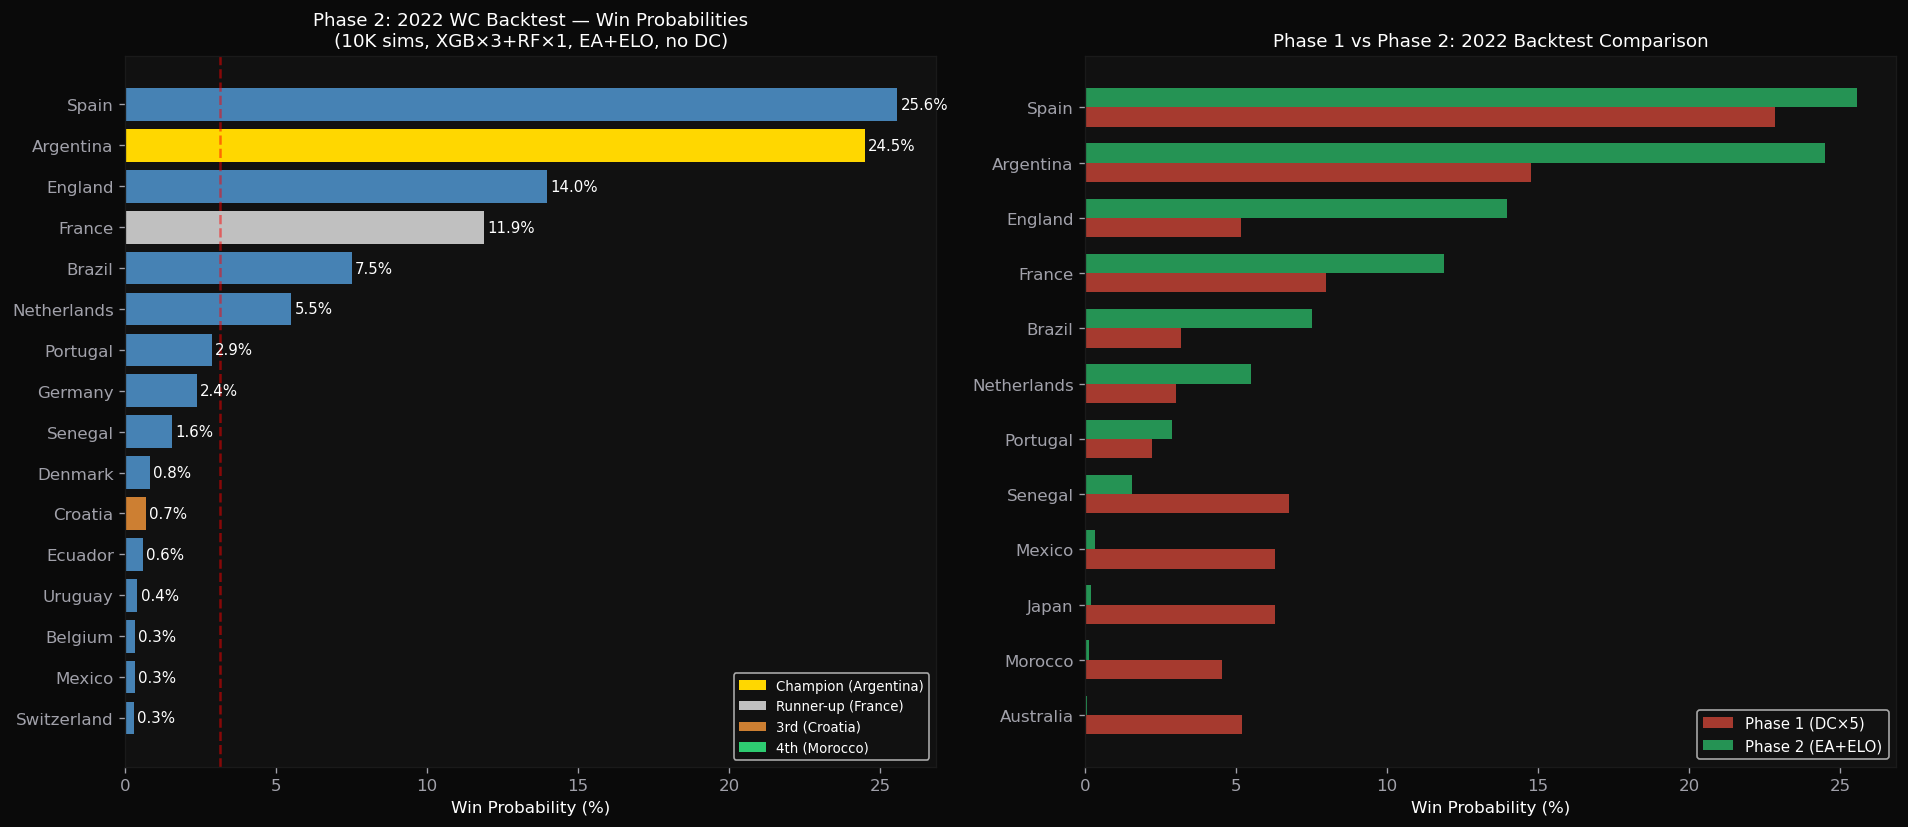

Chart saved.


In [10]:
# Visualization — Phase 2 vs Phase 1 comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Chart 1: Win probabilities
top16 = win_probs.head(16)
actual_finishes = {'Argentina': 'Champion', 'France': 'Runner-up', 'Croatia': '3rd', 'Morocco': '4th'}
bar_colors = ['gold' if t == 'Argentina' else 'silver' if t == 'France'
              else '#CD7F32' if t == 'Croatia' else '#2ecc71' if t == 'Morocco'
              else 'steelblue' for t in top16['team'][::-1]]

ax = axes[0]
bars = ax.barh(top16['team'][::-1], top16['win_pct'][::-1], color=bar_colors)
ax.set_xlabel('Win Probability (%)')
ax.set_title('Phase 2: 2022 WC Backtest — Win Probabilities\n(10K sims, XGB×3+RF×1, EA+ELO, no DC)', fontsize=11)
for bar, val in zip(bars, top16['win_pct'][::-1]):
    ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height() / 2,
            f'{val:.1f}%', va='center', fontsize=9)
ax.axvline(x=100 / 32, color='red', linestyle='--', alpha=0.5)
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='gold', label='Champion (Argentina)'),
                   Patch(facecolor='silver', label='Runner-up (France)'),
                   Patch(facecolor='#CD7F32', label='3rd (Croatia)'),
                   Patch(facecolor='#2ecc71', label='4th (Morocco)')]
ax.legend(handles=legend_elements, fontsize=8, loc='lower right')

# Chart 2: Phase 1 vs Phase 2 comparison
phase1_data = {
    'Spain': 22.86, 'Argentina': 14.77, 'France': 7.98, 'Senegal': 6.76,
    'Mexico': 6.28, 'Japan': 6.27, 'Australia': 5.19, 'England': 5.17,
    'Morocco': 4.53, 'Brazil': 3.17, 'Netherlands': 3.00, 'Portugal': 2.21,
}
common_teams = [t for t in win_probs['team'] if t in phase1_data][:12]
p1_vals = [phase1_data.get(t, 0) for t in common_teams]
p2_vals = [win_probs[win_probs['team'] == t]['win_pct'].values[0] for t in common_teams]

ax2 = axes[1]
x = np.arange(len(common_teams))
w = 0.35
ax2.barh(x + w/2, p1_vals, w, label='Phase 1 (DC×5)', color='#e74c3c', alpha=0.7)
ax2.barh(x - w/2, p2_vals, w, label='Phase 2 (EA+ELO)', color='#2ecc71', alpha=0.7)
ax2.set_yticks(x)
ax2.set_yticklabels(common_teams)
ax2.set_xlabel('Win Probability (%)')
ax2.set_title('Phase 1 vs Phase 2: 2022 Backtest Comparison', fontsize=11)
ax2.legend(fontsize=9)
ax2.invert_yaxis()

plt.tight_layout()
plt.savefig('../images/phase2_06_backtest.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved.')

In [11]:
# Final scorecard
arg_pct = champion_counts.get('Argentina', 0) / N_SIMS * 100
fra_pct = champion_counts.get('France', 0) / N_SIMS * 100
arg_rank = win_probs[win_probs['team'] == 'Argentina'].index[0] + 1
fra_rank = win_probs[win_probs['team'] == 'France'].index[0] + 1

print('=' * 60)
print('PHASE 2 BACKTEST SCORECARD')
print('=' * 60)
print(f'Actual champion:         Argentina')
print(f'Argentina predicted:     {arg_pct:.2f}%  (rank #{arg_rank})')
print(f'France predicted:        {fra_pct:.2f}%  (rank #{fra_rank})')
print(f'Group qual accuracy:     {correct_qualifiers}/{total_slots} = {correct_qualifiers / total_slots * 100:.1f}%')
print(f'Teams that won sim:      {len(win_probs)}')
print()
print('Actual finalists vs predicted rank:')
for team, finish in [('Argentina', 'Champion'), ('France', 'Runner-up'),
                     ('Croatia', '3rd'), ('Morocco', '4th')]:
    r = win_probs[win_probs['team'] == team]
    if len(r):
        pct = r['win_pct'].values[0]
        rnk = r.index[0] + 1
        print(f'  {team:12s} ({finish:10s}) -> win%={pct:.2f}%  rank=#{rnk}')
    else:
        print(f'  {team:12s} ({finish:10s}) -> did not win any sim')

print()
print('Phase 1 comparison:')
print('  Phase 1: Argentina #2 (14.77%), France #3 (7.98%), Group acc 87.5%')
print(f'  Phase 2: Argentina #{arg_rank} ({arg_pct:.2f}%), France #{fra_rank} ({fra_pct:.2f}%), Group acc {correct_qualifiers / total_slots * 100:.1f}%')
print()
print('Confederation bias check (Phase 1 -> Phase 2):')
for team in ['Mexico', 'Senegal', 'Japan', 'Australia']:
    p1 = phase1_data.get(team, 0)
    r = win_probs[win_probs['team'] == team]
    p2 = r['win_pct'].values[0] if len(r) else 0
    print(f'  {team:12s}: {p1:.2f}% -> {p2:.2f}%  (delta {p2-p1:+.2f})')
print('=' * 60)

win_probs.to_csv('../../data/processed/wc2022_backtest_results_phase2.csv', index=False)
print('\nResults saved to wc2022_backtest_results_phase2.csv')

PHASE 2 BACKTEST SCORECARD
Actual champion:         Argentina
Argentina predicted:     24.51%  (rank #2)
France predicted:        11.89%  (rank #4)
Group qual accuracy:     9/16 = 56.2%
Teams that won sim:      27

Actual finalists vs predicted rank:
  Argentina    (Champion  ) -> win%=24.51%  rank=#2
  France       (Runner-up ) -> win%=11.89%  rank=#4
  Croatia      (3rd       ) -> win%=0.69%  rank=#11
  Morocco      (4th       ) -> win%=0.12%  rank=#19

Phase 1 comparison:
  Phase 1: Argentina #2 (14.77%), France #3 (7.98%), Group acc 87.5%
  Phase 2: Argentina #2 (24.51%), France #4 (11.89%), Group acc 56.2%

Confederation bias check (Phase 1 -> Phase 2):
  Mexico      : 6.28% -> 0.31%  (delta -5.97)
  Senegal     : 6.76% -> 1.55%  (delta -5.21)
  Japan       : 6.27% -> 0.18%  (delta -6.09)
  Australia   : 5.19% -> 0.06%  (delta -5.13)

Results saved to wc2022_backtest_results_phase2.csv
